In [2]:
import pyLIMA, os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyLIMA import event, telescopes
from pyLIMA.simulations import simulator
from pyLIMA.models import FSPL_model,USBL_model,PSPL_model
from ipywidgets import interactive, HBox, VBox, Layout
from ipywidgets import (FloatSlider, FloatLogSlider, interactive_output, HBox, VBox, GridBox, Layout, Label)
from IPython.display import display
current_path = os.getcwd()
parent_directory = os.path.abspath(os.path.join(current_path, os.pardir))
print("Parent Directory:", parent_directory)
sys.path.append(parent_directory)
import pyLIMA_plots
from astropy import units as u
from astropy import constants as C
from pyLIMA.xallarap.xallarap import xallarap_shifts, compute_xallarap_curvature


Parent Directory: /home/anibal-pc/microlensing/simulation_Rubin/roman_rubin


In [38]:
#create dataframe with the events 
data = [
    # Event 1
    {
        "Event": 1,
        "t_0": 50,
        "u_0": 0.05,
        "t_E": 12,
        "f_s": 1,
        "flux_ratio": 0.1,
        "xi_mass_ratio": 0.5,
        "P": 0.4,
        "xiE": 0.01,
        "xi_inclination": 0,
        "xi_phase": 0
    },
    # Event 2
    {
        "Event": 2,
        "t_0": 50,
        "u_0": 0.5,
        "t_E": 35,
        "f_s": 1,
        "flux_ratio": 0.1,
        "xi_mass_ratio": 0.5,
        "P": 60,
        "xiE": 0.2,
        "xi_inclination": 0,
        "xi_phase": 0
    },
    # Event 3
    {
        "Event": 3,
        "t_0": 50,
        "u_0": 0.2,
        "t_E": 30,
        "f_s": 1,
        "flux_ratio": 0.1,
        "xi_mass_ratio": 0.5,
        "P": 25,
        "xiE": 0.1,
        "xi_inclination": np.pi/4,
        "xi_phase": 0
    },
    # Event 4
    {
        "Event": 4,
        "t_0": 50,
        "u_0": 0.1,
        "t_E": 25,
        "f_s": 1,
        "flux_ratio": 0.1,
        "xi_mass_ratio": 0.5,
        "P": 7,
        "xiE": 0.05,
        "xi_inclination": 0,
        "xi_phase": 0
    },
    # Event 5
    {
        "Event": 5,
        "t_0": 50,
        "u_0": 0.3,
        "t_E": 15,
        "f_s": 1,
        "flux_ratio": 0.1,
        "xi_mass_ratio": 0.5,
        "P": 1.5,
        "xiE": 0.02,
        "xi_inclination": 0,
        "xi_phase": 0
    }
]

df = pd.DataFrame(data)
display(df)


,Event,t_0,u_0,t_E,f_s,flux_ratio,xi_mass_ratio,P,xiE,xi_inclination,xi_phase
0,1,50,0.05,12,1,0.1,0.5,0.4,0.01,0.000000,0
1,2,50,0.50,35,1,0.1,0.5,60.0,0.20,0.000000,0
2,3,50,0.20,30,1,0.1,0.5,25.0,0.10,0.785398,0
3,4,50,0.10,25,1,0.1,0.5,7.0,0.05,0.000000,0
4,5,50,0.30,15,1,0.1,0.5,1.5,0.02,0.000000,0


# Create event, define telescope and choose a model

PyLIMA need that we specify the compontents of $\xi_{E}=(\xi_{E \parallel},\xi_{E \perp}) = $.

Where $\xi_{E \parallel}=\xi_E \cos(\theta)$ and $\xi_{E \perp}=\xi_E \sin(\theta)$.


In [40]:
# ---- Event & telescope ----
simulated_event = event.Event()
simulated_event.name = 'Simulated'
simulated_event.ra = 170
simulated_event.dec = -70

time_sim = np.linspace(0, 100, 500)
lightcurve_sim = np.c_[time_sim, np.full_like(time_sim, 19.0), np.full_like(time_sim, 0.01)]

tel = telescopes.Telescope(
    name='Simulation',
    camera_filter='G',
    lightcurve=lightcurve_sim.astype(float),
    lightcurve_names=['time','mag','err_mag'],
    lightcurve_units=['JD','mag','mag'],
    location='Earth'
)
simulated_event.telescopes.append(tel)

params_list = [0]*12
i=0  # <---- PICK THE FIRST EVENT
df_row = df.iloc[i]  # <---- PICK THE FIRST EVENT
params_list[0] = df_row['t_0'] 
params_list[1] = df_row['u_0'] 
params_list[2] = df_row['t_E'] 
params_list[3] = df_row['xiE']*np.cos(0) # <---- THE SOURCE BINARY SISTEM MOVES PARALLEL TO THE SEMI MAJOR AXIS
params_list[4] = df_row['xiE']*np.sin(0) # <---- THE SOURCE BINARY SISTEM MOVES PARALLEL TO THE SEMI MAJOR AXIS
params_list[5] = 2*np.pi/df_row['P']
params_list[6] = df_row['xi_phase']   #< ---- Orbital phase at t0
params_list[7] = df_row['xi_inclination']
params_list[8] = df_row['xi_mass_ratio']
params_list[9] = df_row['flux_ratio']
params_list[10] = 1 # <---- FLUX IS NOT RELEVANT TO A(t) COMPUTATION
params_list[11] = 1 # <---- FLUX BLENDING IS NOT RELEVANT TO A(t) COMPUTATION

model = PSPL_model.PSPLmodel(simulated_event, parallax=['None', 0], double_source=['Circular', df_row['t_0']]) # <--- Here I set t0,xi = t0
model.define_model_parameters()

plt.close("all")
%matplotlib inline
py_params = model.compute_pyLIMA_parameters(params_list)
print("pyLIMA parameters", py_params)

A = model.model_magnification(model.event.telescopes[0], py_params)
# plt.figure(dpi=120)
# plt.plot(time_sim, A, label="DSPL")
# plt.xlabel("Time")
# plt.ylabel(r"$A(t)$")
# plt.legend()
# plt.tight_layout()
# plt.show()


pyLIMA parameters OrderedDict({'t0': np.float64(50.0), 'u0': np.float64(0.05), 'tE': np.float64(12.0), 'xi_para': np.float64(0.01), 'xi_perp': np.float64(0.0), 'xi_angular_velocity': np.float64(15.707963267948966), 'xi_phase': np.float64(0.0), 'xi_inclination': np.float64(0.0), 'xi_mass_ratio': np.float64(0.5), 'q_flux_G': np.float64(0.1), 'fsource_Simulation': 1, 'ftotal_Simulation': 1})


# Here we plot the trajectory

(<Figure size 700x700 with 1 Axes>, None)

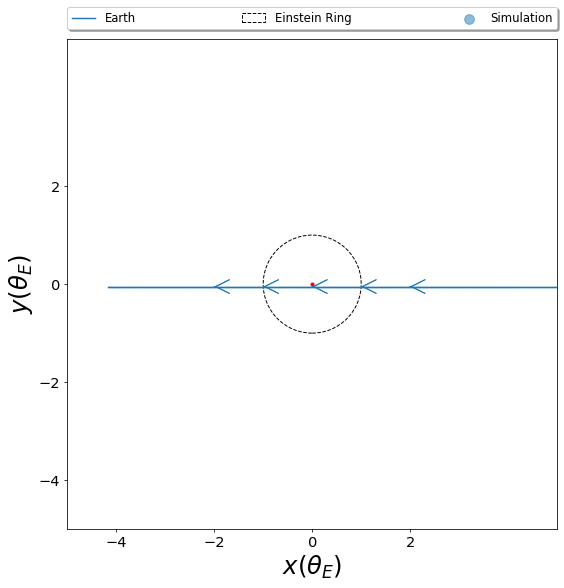

In [56]:
# With pyLIMA
pyLIMA_plots.plot_geometry(model,params_list)

# Computation of Xallarap Trajectories in PyLIMA

Here I want to explain what is the computation that pyLIMA does internally.

In the $\texttt{PyLIMA}$ implementation of xallarap, the code reconstructs the
projected orbital motion of a binary source system using only a small set of
dimensionless input parameters. PyLIMA works entirely in units of the
Einstein radius and reconstructs a \emph{normalized orbital trajectory}, which
is then rescaled by the xallarap amplitude vector.

The user provides the following inputs:

$$
\bigl\{
t_0,\; t_E,\; u_0,\;
\xi_{\parallel},\;\xi_{\perp},\;
\omega_\xi,\;\phi_\xi,\;\lambda_\xi,\;q_\xi
\bigr\},
$$

where:

* $\xi_{\parallel},\xi_{\perp}$ are the components of the xallarap amplitude
    vector $\vec{\xi}_E$,
* $\omega_\xi = 2\pi/P_\xi$ is the angular orbital frequency,
* $\phi_\xi$ is the orbital phase at the reference time,
* $\lambda_\xi$ is the inclination of the orbital plane,
* $q_\xi = M_2/M_1$ is the mass ratio of the source binary.
* Also we need to set $t_{0,\xi}$ reference time where the perturbation induced by xallarap is zero. We choose this time as $t0$.


## 1. Normalized circular orbit in PyLIMA

PyLIMA first constructs a \emph{unit-radius} circular orbit in the projected sky
plane:

$$
\Omega(t) = \omega_\xi \,(t - t_{0,\xi}) + \phi_\xi,
$$

$$
S_x(t) = \cos\Omega(t), \qquad
S_y(t) = \sin\lambda_\xi \,\sin\Omega(t).
$$

These functions are implemented in the routine
$\texttt{circular\_xallarap()}$ and represent a purely geometrical,
dimensionless orbit. No semimajor axis is used here; the trajectory implicitly
has radius unity.

## 2. Barycentric scaling of each source

Given the mass ratio $q_\xi = M_2/M_1$, the distances of the two stars from the
barycenter are, in physical units,

$$
r_1 = \frac{q_\xi}{1+q_\xi}a, \qquad
r_2 = \frac{1}{1+q_\xi}a.
$$

PyLIMA does not know $a$; therefore it rescales the \emph{unit} orbit by the
dimensionless factors:

$$
\alpha_1 = \frac{q_\xi}{1+q_\xi}, \qquad
\alpha_2 = \frac{1}{q_\xi}\alpha_1 = \frac{1}{1+q_\xi}.
$$

Thus the normalized barycentric orbits become

$$
X_1(t) = \alpha_1 S_x(t), \qquad 
Y_1(t) = \alpha_1 S_y(t),
$$

$$
X_2(t) = -\alpha_2 S_x(t), \qquad 
Y_2(t) = -\alpha_2 S_y(t).
$$

These are exactly the quantities returned by \texttt{xallarap\_shifts()}.

## 3. Removing the initial offset

PyLIMA enforces that at the reference epoch $t_{0,\xi}$ the displacement must vanish:
$$
S_x(t_0)=0, \qquad S_y(t_0)=0.
$$

Thus it subtracts
$$
\cos\phi_\xi, \qquad \sin\lambda_\xi \sin\phi_\xi
$$
from the expressions above before returning them.

## 4. Converting physical shifts into Einstein units

The xallarap amplitude vector is
$$
\vec{\xi}_E = (\xi_{\parallel}, \xi_{\perp}).
$$

The displacement that enters the microlensing trajectory is

$$
\delta\tau = 
\xi_{\parallel} S_x(t) + \xi_{\perp} S_y(t),
$$

$$
\delta\beta =
\xi_{\parallel} S_y(t) - \xi_{\perp} S_x(t).
$$

These expressions are implemented in
\texttt{compute\_xallarap\_curvature()} and correspond to projecting the
orbital motion onto the $(\tau,\beta)$ axes.

## 5. Full lens–source separation vectors

For each source $i\in\{1,2\}$:
$$
\tau_i(t) = \frac{t - t_0}{t_E} + \delta\tau_i(t),
\qquad
\beta_i(t) = u_0 + \delta\beta_i(t).
$$

The total instantaneous separation is

$$
u_i(t) = \sqrt{\tau_i(t)^2 + \beta_i(t)^2}.
$$

## 6. Magnification

The magnification of each source is

$$
A_i(t) = \frac{u_i^2+2}{u_i\sqrt{u_i^2+4}},
$$

and the combined flux for a binary source is

$$
A(t) = A_1(t) + q_{\rm flux} A_2(t),
$$

where $q_{\rm flux}$ is the ratio of unlensed fluxes.



Thus PyLIMA reconstructs the full xallarap-induced trajectories and magnification curves using only dimensionless orbital parameters, Einstein-radius normalization, and geometric projection. No explicit semimajor axis $a$ is required; it is absorbed into the definition of $\xi_E$, which determines the amplitude of the normalized orbit.


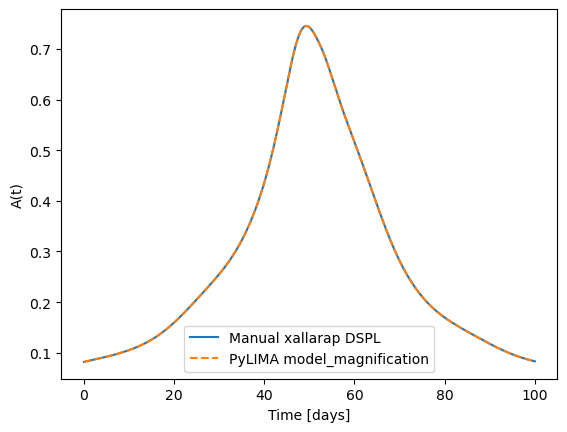

In [30]:

def pspl_magnification(u):
    """Magnification for a point source–point lens."""
    return (u**2 + 2.0) / (u * np.sqrt(u**2 + 4.0))

def manual_xallarap_DSPL_magnification(model, py_params, tel_name='Simulation'):
    """
    Reconstruct A(t) directly using:
    - xallarap_shifts
    - compute_xallarap_curvature
    and the PSPL formula for each source.
    """
    # --- 1) Time and basic parameters ---
    tel = [t for t in model.event.telescopes if t.name == tel_name][0]
    time = tel.lightcurve['time'].value

    t0  = py_params['t0']
    tE  = py_params['tE']
    u0  = py_params['u0']

    tau  = (time - t0) / tE
    beta = np.full_like(tau, u0, dtype=float)

    # --- 2) Xallarap model used by PyLIMA in this model ---
    # For a model created as PSPLmodel(..., double_source=['Circular', t0_xi])
    xallarap_model = (model.double_source_model[0], model.double_source_model[1])
    # typically ('Circular', t0_xi) and that t0_xi usually matches t0

    # --- 3) Normalized orbits of the two sources (in the S basis) ---
    # Returns:
    #   separation_1_1, separation_2_1  -> S1x(t), S1y(t) for source 1
    #   separation_1_2, separation_2_2  -> S2x(t), S2y(t) for source 2
    S1x, S1y, S2x, S2y = xallarap_shifts(xallarap_model, time, py_params, body='primary')

    # --- 4) Xallarap vector components (xi_para, xi_perp) ---
    xiE = np.array([py_params['xi_para'], py_params['xi_perp']], dtype=float)

    # To use compute_xallarap_curvature we need delta_positions as [d_N, d_E]
    # Here we interpret (Sx, Sy) as (N, E) in normalized Einstein units.
    S1 = np.vstack([S1x, S1y])
    S2 = np.vstack([S2x, S2y])

    # Displacements (delta_tau, delta_beta) for each source
    d_tau1, d_beta1 = compute_xallarap_curvature(xiE, S1)
    d_tau2, d_beta2 = compute_xallarap_curvature(xiE, S2)

    # --- 5) Full trajectories of each source in (tau, beta) ---
    tau1  = tau + d_tau1
    beta1 = beta + d_beta1

    tau2  = tau + d_tau2
    beta2 = beta + d_beta2

    # --- 6) Lens–source separation in Einstein units ---
    u1 = np.sqrt(tau1**2 + beta1**2)
    u2 = np.sqrt(tau2**2 + beta2**2)

    # --- 7) PSPL magnification for each source ---
    A1 = pspl_magnification(u1)
    A2 = pspl_magnification(u2)

    # --- 8) Combine the two sources using q_flux of the corresponding band ---
    # In your example: q_flux_G = 0.1 (flux of source 2 / flux of source 1).
    q_flux = py_params['q_flux_G']

    # If the baseline flux is F1 + F2, the effective magnification is:
    A = A1 + q_flux * A2

    return time, A

# Example of usage with your model and parameters:
time_manual, A_manual = manual_xallarap_DSPL_magnification(model, py_params)
A_pyLIMA = model.model_magnification(model.event.telescopes[0], py_params)

plt.xlabel("Time [days]")
plt.ylabel("A(t)")
plt.plot(time_manual, np.log10(A_manual), label='Manual xallarap DSPL')
plt.plot(time_sim, np.log10(A_pyLIMA), '--', label='PyLIMA model_magnification')
plt.legend(); plt.show()
